In [1]:
import pandas as pd 
import os 

In [217]:
import nltk
import numpy as np
from nltk.corpus import stopwords
 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lamda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [125]:
# stopwords.words('english')[:15]

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours']

In [218]:
# stopwords.words('english')[39:]

In [160]:
en_stops = stopwords.words('english')[39:]
en_stops.append(',')
en_stops.append('?')
en_stops[:3]

['this', 'that', "that'll"]

In [161]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')

In [187]:
data = pd.read_csv(os.path.join(data_path, 'dsm_pilot.csv'))
data.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,annot
0,t3_5kwodh,depression,Iluvmychildren,"I am not depressed right now, but I say to may...",comment,1.483034e+09,t3_5kwodh,dbrghop,14,0,1
1,5vopn7,depression,derpynarwhal9,I'm twenty five and the earliest I can for sur...,post,1.487830e+09,5vopn7,5vopn7,17,0,0
2,t3_9boomi,depression,Belial42069,This whole subreddit is built around talking b...,comment,1.535674e+09,t3_9boomi,e54l8nt,10,0,3


In [188]:
data.text = data.text.apply(lambda x: x.replace("'m", ' am'))
data.text = data.text.apply(lambda x: x.replace("can't", "can not"))
data.text = data.text.apply(lambda x: x.replace("don't", "do not"))
data.text = data.text.apply(lambda x: x.replace("didn't", "did not"))
data.text = data.text.apply(lambda x: x.replace("'re", " are"))
data.text = data.text.apply(lambda x: x.replace("'s", ' is'))
data.text = data.text.apply(lambda x: x.replace("'ve", ' have'))
data.text = data.text.apply(lambda x: x.replace(",", ' '))
data.text = data.text.apply(lambda x: x.replace("that's", "that is"))

In [189]:
a1 = data[data.label==0]
a1.groupby('annot').count()

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label
annot,,,,,,,,,,
0,568,568,568,568,568,568,568,568,568,568
1,164,164,164,164,164,164,164,164,164,164
2,1,1,1,1,1,1,1,1,1,1
3,267,267,267,267,267,267,267,267,267,267


In [190]:
a1.loc[7].text

'Why do some people say I am not really depressed because I did not go to the doctors?'

In [191]:
from nltk.tokenize import word_tokenize

In [192]:
a1_group1 = []; a1_group2 = []; a1_group3 = []

for idx in range(len(a1)):
    if a1.annot[idx] == 0: 
        a1_group1.append(word_tokenize(a1.text[idx]))
    elif a1.annot[idx] == 1:
        a1_group2.append(word_tokenize(a1.text[idx]))
    elif a1.annot[idx] == 3:
        a1_group3.append(word_tokenize(a1.text[idx]))

In [193]:
group1 = []; group2 = []; group3 = [] 

for idx in range(len(data)):
    if data.annot[idx] == 0: 
        group1.append(word_tokenize(data.text[idx]))
    elif data.annot[idx] == 1:
        group2.append(word_tokenize(data.text[idx]))
    elif data.annot[idx] == 3:
        group3.append(word_tokenize(data.text[idx]))

In [194]:
len(a1_group1), len(a1_group2), len(group1)

(568, 164, 3969)

In [195]:
from matplotlib import pyplot as plt 
from collections import Counter

counter = Counter

In [196]:
a1_group1_total = []; a1_group2_total = []; a1_group3_total = []

for tok_list in a1_group1:
    a1_group1_total.extend(tok_list)
    
for tok_list in a1_group2:
    a1_group2_total.extend(tok_list)
    
for tok_list in a1_group3:
    a1_group3_total.extend(tok_list)

In [197]:
group1_total = []; group2_total = []; group3_total = []

for tok_list in group1:
    group1_total.extend(tok_list)
    
for tok_list in group2:
    group2_total.extend(tok_list)
    
for tok_list in group3:
    group3_total.extend(tok_list)

In [174]:
a1_group1_total = [tok for tok in a1_group1_total if tok not in en_stops]
a1_group2_total = [tok for tok in a1_group2_total if tok not in en_stops]
a1_group3_total = [tok for tok in a1_group3_total if tok not in en_stops]
len(a1_group1_total)

6215

In [175]:
group1_total = [tok for tok in group1_total if tok not in en_stops]
group2_total = [tok for tok in group2_total if tok not in en_stops]
group3_total = [tok for tok in group3_total if tok not in en_stops]

In [198]:
a1_group2_total[:3]

['I', 'am', 'not']

In [199]:
a1_group1_df = pd.DataFrame(sorted(dict(counter(a1_group1_total)).items(), key=lambda x: x[1], reverse=True), columns=['tok', 'cnt'])
a1_group1_df.head(3)

,tok,cnt
0,I,853
1,and,399
2,depressed,339


In [200]:
group1_df = pd.DataFrame(sorted(dict(counter(group1_total)).items(), key=lambda x: x[1], reverse=True), columns=['tok', 'cnt'])
group1_df.head(3)

,tok,cnt
0,I,5214
1,and,2659
2,to,2081


In [201]:
a1_group2_df = pd.DataFrame(sorted(dict(counter(a1_group2_total)).items(), key=lambda x: x[1], reverse=True), columns=['tok', 'cnt'])
a1_group2_df.head(3)

,tok,cnt
0,I,271
1,to,108
2,depressed,103


In [202]:
a1_group3_df = pd.DataFrame(sorted(dict(counter(a1_group3_total)).items(), key=lambda x: x[1], reverse=True), columns=['tok', 'cnt'])
a1_group3_df.head(3)

,tok,cnt
0,depressed,180
1,you,172
2,to,162


In [203]:
group2_df = pd.DataFrame(sorted(dict(counter(group2_total)).items(), key=lambda x: x[1], reverse=True), columns=['tok', 'cnt'])
group2_df.head(3)

,tok,cnt
0,I,1959
1,to,958
2,and,789


In [204]:
group1_df.head(10)

,tok,cnt
0,I,5214
1,and,2659
2,to,2081
3,the,1342
4,my,1272
5,of,1186
6,a,1173
7,have,1057
8,am,919
9,not,875


In [243]:
top_a1_group1 = a1_group1_df.head(10)
top_a1_group2 = a1_group2_df.head(10)
top_a1_group3 = a1_group3_df.head(10)

In [245]:
top_a1_group = top_a1_group1.merge(top_a1_group2, on='tok', how='outer')
top_a1_group = top_a1_group.merge(top_a1_group3, on='tok', how='outer')
top_a1_group.fillna(0, inplace=True)
top_a1_group.columns = ['tok', 'group_a', 'group_b', 'group_c']
top_a1_group.head(3)

,tok,group_a,group_b,group_c
0,I,853.0,271.0,81.0
1,and,399.0,66.0,116.0
2,depressed,339.0,103.0,180.0


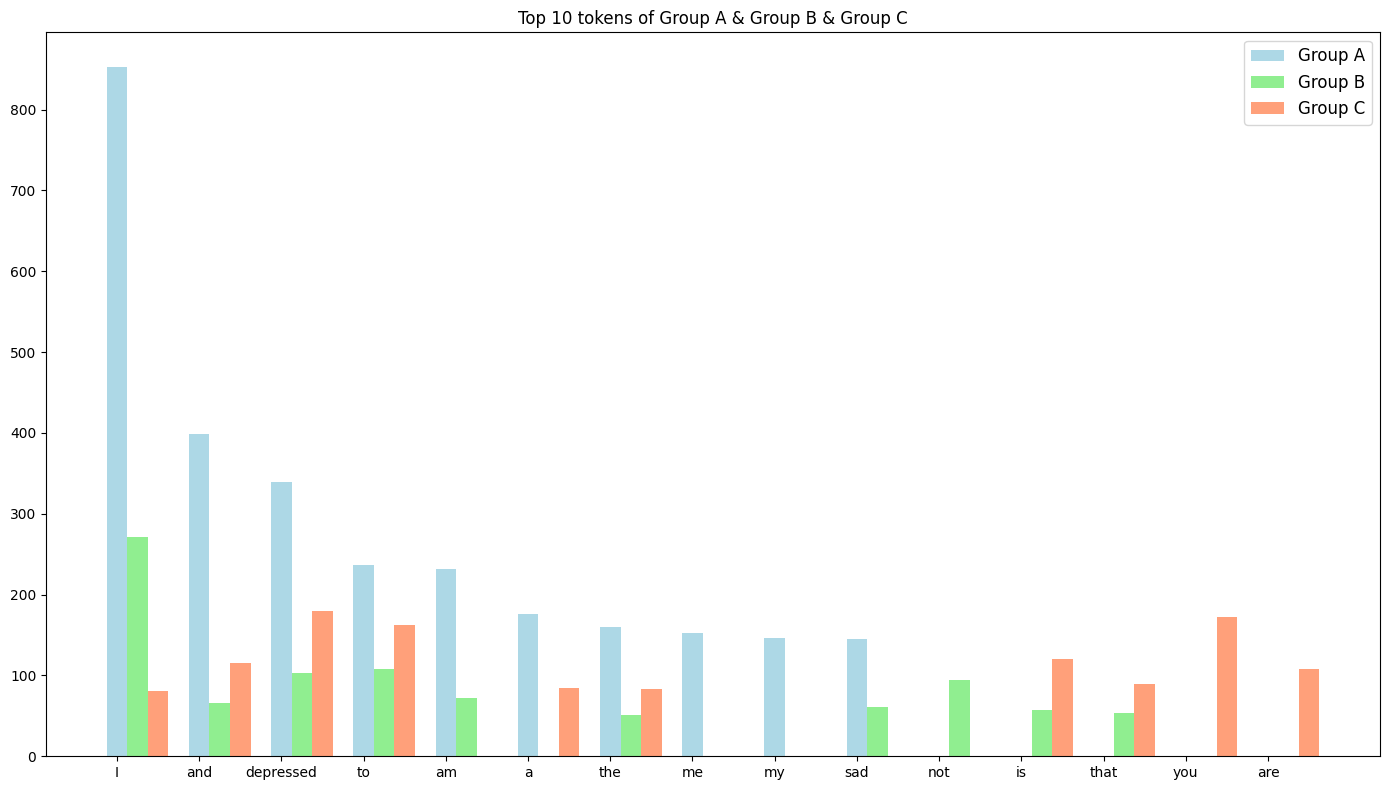

In [249]:
plt.figure(figsize=(14, 8))

index = np.arange(len(top_a1_group))
bar_width = 0.25 

plt.bar(index, top_a1_group.group_a, bar_width, color='lightblue', label='Group A')
plt.bar(index + bar_width, top_a1_group.group_b, bar_width, color='lightgreen', label='Group B')
plt.bar(index + bar_width * 2, top_a1_group.group_c, bar_width, color='lightsalmon', label='Group C')
plt.title('Top 10 tokens of Group A & Group B & Group C')
plt.xticks(range(len(top_a1_group)), top_a1_group.tok)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()